# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

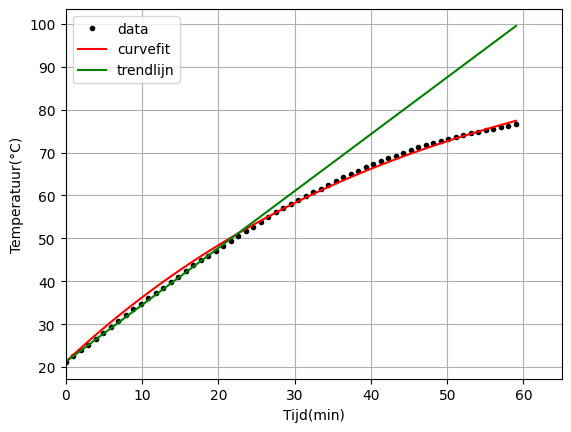

In [14]:
#data
data = np.loadtxt('Temp_Metingen.csv', delimiter=';', skiprows=1)
T_e = 100
T_0 = 21.2

x = np.arange(0, 60, 60/len(data))
y_data = data[:,1]

#fits
def Func(x, g):
    return T_e-(T_e-T_0)*(g**x)
val, cov = curve_fit(Func, x, y_data)

def trendlijn(x, a):
    return a*x + T_0
val1, cov1 = curve_fit(trendlijn, x[0:25], y_data[0:25])

# Maken van de grafiek
plt.figure()

plt.xlabel('Tijd(min)')
plt.ylabel('Temperatuur(°C)')
plt.xlim(0, 65)
plt.plot(x, y_data, 'k.', label='data')
plt.plot(x, Func(x, val), c='r', label='curvefit')
plt.plot(x, trendlijn(x, val1[0]), c='g', label='trendlijn')

plt.legend()
plt.grid()
plt.show()

In [ ]:
#Berekeningen verder..
m_water_begin = 1.2929-0.8208 # kg
m_water_eind = 1.2749-0.8028 # kg
m_water_verdampt = m_water_begin - m_water_eind # kg
c_water = 4.184  # kJ/(kg· K) 
verdampingswarmte_water = 2260  # kJ/kg

#Aannames: (1) Alle warmte gaat naar het water, niks naar de omgeving. (2) Het niet verdampte gedeelte van het water wordt opgewarmd tot de maximale temperatuur bereikt in de grafiek.
# (3) Het verdampte water wordt eerst tot 100 graden celcius opgewarmd en daarna verdampt. (4) De totale toegevoegde warmte volgt uit de trendlijn van het lineaire gedeelte van de grafiek.
Q_verwarming = m_water_begin * c_water * (np.max(y_data) - T_0) + m_water_verdampt * c_water * (T_e - np.max(y_data))  # kJ
Q_verdamping = m_water_verdampt * verdampingswarmte_water  # kJ
Q_totaal = Q_verwarming + Q_verdamping  # kJ
#Volgens de trendlijn van het nog lineare gedeelte van de (t,T)-grafiek is de totale warmte-instroom:
Q_trend = m_water_begin * c_water * (trendlijn(60, val1[0]) - T_0)  # kJ

print(f"Totale warmte volgens aannames: {Q_totaal:.3f} kJ")
print(f"Totale warmte volgens trendlijn: {Q_trend:.3f} kJ")
print(f"Verschil in warmte: {abs(Q_totaal - Q_trend):.3f} kJ") 


#Met een verschil van theorie en meting van 10 graden Kelvin van uiteindelijke temperatuur, kom ik uit op een verschil in energie van 19.385 KJ. Dit met verdampingsenergie van water om te rekenen naar een verwachte 8.6g verdamping van water. Dit is wat lager dan wat we zien namelijk 20g maar dat kan komen door weglekking van warmte naar het glas en dat er een kamer temperatuurverschil was met de aangenomen waarde van 20 graden celsius.

Totale warmte volgens aannames: 109.430 kJ
Totale warmte volgens trendlijn: 157.268 kJ
Verschil in warmte: 47.838 kJ


# Discussie en Conclusie
Zoals te zien is de warmte ingevoerd significant groter dan de theoretisch benodigde waarde. Er is dus veel warmte uitgestroomd naar de omgeving.